In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install -qq ultralytics
from ultralytics import YOLO
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
!git config --global user.name "apeas1"
!git config --global user.email "miguelmuba01@gmail.com"

In [10]:
!git clone https://[TOKEN]@github.com/apeas1/PIDDeteccionVehiculos.git

Cloning into 'PIDDeteccionVehiculos'...
remote: Enumerating objects: 4993, done.
remote: Total 4993 (delta 0), reused 0 (delta 0), pack-reused 4993 (from 2)
Receiving objects: 100% (4993/4993), 334.68 MiB | 42.10 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (7415/7415), done.


In [2]:
!pip install -qq roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="oLgrOUnp0TT0CVeH8mYq")
project = rf.workspace("sardar-vallabhbhai-national-institute-if-technology").project("vehicle-detection-wagr7")
version = project.version(3)
dataset = version.download("yolov8-obb")


dataset = version.download("yolov8")
print("Dataset descargado en:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 106.8 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VEHICLE-DETECTION-3 in yolov8-obb:: 100%|██████████| 7420/7420 [00:02<00:00, 3299.53it/s]


Dataset descargado en: /content/VEHICLE-DETECTION-3


In [32]:
%%writefile dataset.yaml
path: VEHICLE-DETECTION-3
train: train/images
val: valid/images
test: test/images



names:
  0: 3W
  1: Bus
  2: Coche
  3: Camioneta
  4: Motocicleta
  5: Camión Abierto
  6: Camion


Writing dataset.yaml


In [40]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2010_dataaug/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test

img = mpimg.imread('runs/detect/val/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1443.6±458.6 MB/s, size: 88.6 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 239.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.8s/it 1:49
                   all        252      27305      0.652      0.618      0.644      0.304
                    3W        251       2972      0.727       0.59      0.613      0.215
                   Bus        125        364      0.674      0.852      0.846      0.493
                 Coche        251       8362      0.751      0.836      0.823      0.372
             Camioneta        182       1176      0.659      0.502      0.597        0.3
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation
Precisión: 0.6515948247527356
Recall: 0.6184169413322932
F1 score: 0.6194110941344795
Matriz de confusión:


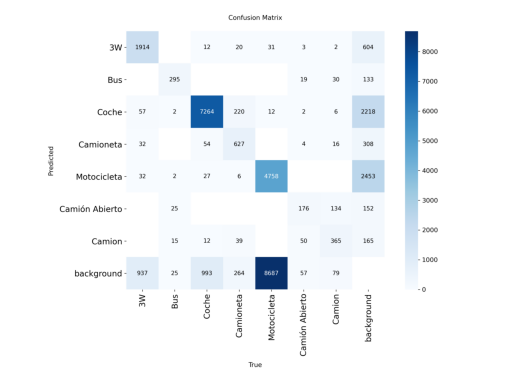

In [41]:
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img)
plt.axis('off')
plt.show()

In [43]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2010/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test
img2 = mpimg.imread('runs/detect/val2/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 766.6±218.8 MB/s, size: 90.9 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 252.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 7.1s/it 1:53
                   all        252      27305      0.732       0.73      0.763      0.408
                    3W        251       2972      0.779      0.703      0.753      0.294
                   Bus        125        364      0.824       0.86      0.915      0.599
                 Coche        251       8362      0.834      0.907      0.901      0.467
             Camioneta        182       1176       0.73      0.709      0.758      0.422
           Mo

Para el modelo entrenado con 20 epochs, tamaño de batch de 10 , iou 0.35, conf 0.45
Precisión: 0.7322309779143846
Recall: 0.7302904508316461
F1 score: 0.721103932554634
Matriz de confusión:


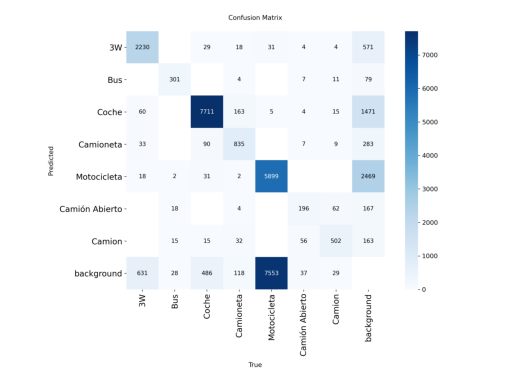

In [44]:
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 10")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img2)
plt.axis('off')
plt.show()

In [45]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento308/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test
img3 = mpimg.imread('runs/detect/val3/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1208.9±385.6 MB/s, size: 92.6 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 259.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.2s/it 1:39
                   all        252      27305      0.738      0.787      0.793       0.44
                    3W        251       2972       0.79      0.764       0.79      0.331
                   Bus        125        364      0.839      0.945      0.932      0.646
                 Coche        251       8362      0.846      0.925      0.922      0.497
             Camioneta        182       1176      0.742      0.754      0.792      0.449
           M

Para el modelo entrenado con 30 epochs, tamaño de batch de 8
Precisión: 0.7378976443247127
Recall: 0.7872683028524462
F1 score: 0.7540966315038802
Matriz de confusión:


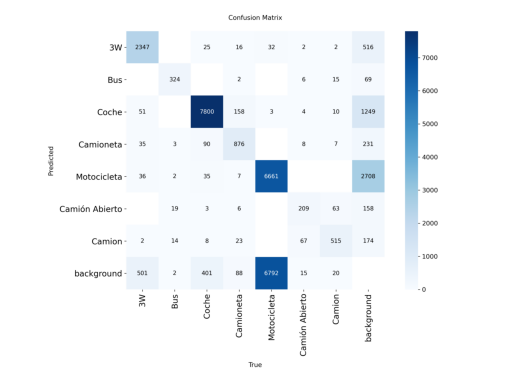

In [46]:
print("Para el modelo entrenado con 30 epochs, tamaño de batch de 8")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img3)
plt.axis('off')
plt.show()

In [47]:
#MÉTRICAS TEST
model = YOLO("Modelos/Entrenamiento2025/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test
img4 = mpimg.imread('runs/detect/val4/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1241.1±208.5 MB/s, size: 83.6 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 266.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.4s/it 1:42
                   all        252      27305      0.737      0.751      0.773       0.42
                    3W        251       2972      0.785      0.711      0.762      0.303
                   Bus        125        364      0.848      0.931      0.935      0.631
                 Coche        251       8362      0.829      0.916      0.907      0.474
             Camioneta        182       1176      0.778      0.692      0.767      0.432
           M

Para el modelo entrenado con 20 epochs, tamaño de batch de 25
Precisión: 0.7371159203924007
Recall: 0.750553565273125
F1 score: 0.7343617183823593
Matriz de confusión:


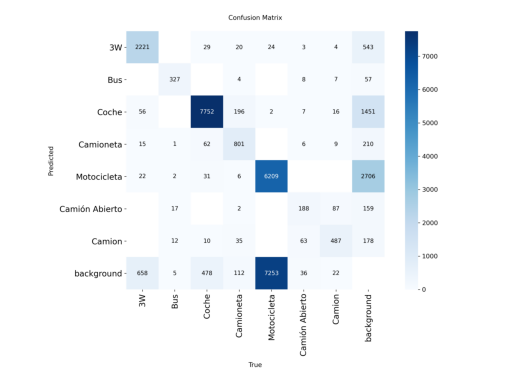

In [48]:
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img4)
plt.axis('off')
plt.show()

In [ ]:
#MÉTRICAS TEST
model = YOLO("Modelos/weights_dataAug_1/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test
img5 = mpimg.imread('runs/detect/val5/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 994.7±204.8 MB/s, size: 86.1 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 277.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 12% ━─────────── 2/16 15.3s/it 16.0s<3:34

Para el modelo entrenado con 20 epochs, tamaño de batch de 25
Precisión: 0.6328082997705078
Recall: 0.6159479204128777
F1 score: 0.6093742096984931
Matriz de confusión:


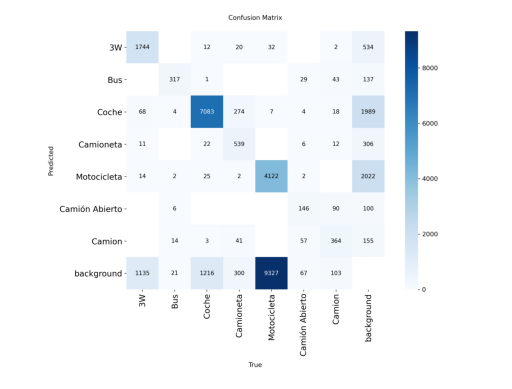

In [ ]:
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25, con data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img5)
plt.axis('off')
plt.show()

In [ ]:
#MÉTRICAS TEST
model = YOLO("Modelos/weights_no_dataAug/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test
img6 = mpimg.imread('runs/detect/val6/confusion_matrix.png')


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1902.7±360.3 MB/s, size: 88.5 KB)
val: Scanning /content/VEHICLE-DETECTION-3/test/labels.cache... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 407.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.4s/it 22.0s
                   all        252      27305      0.735      0.718      0.749      0.401
                    3W        251       2972      0.759      0.678      0.726      0.283
                   Bus        125        364       0.82      0.909      0.917       0.61
                 Coche        251       8362       0.83      0.894      0.896      0.459
             Camioneta        182       1176      0.775      0.673      0.739       0.41
           Motocicleta        252   

Para el modelo entrenado con 20 epochs, tamaño de batch de 25
Precisión: 0.7353999818007659
Recall: 0.7178874543183228
F1 score: 0.7191029048876196
Matriz de confusión:


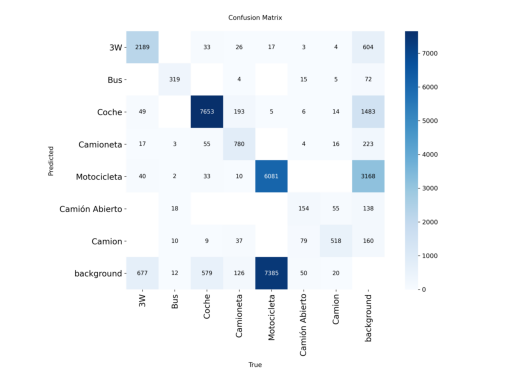

In [ ]:
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 25 y sin data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img6)
plt.axis('off')
plt.show()

In [39]:
rm -rf runs

In [35]:
!git add --

In [ ]:
!git commit -m ""

In [ ]:
!git push origin main